In [1]:
import ROOT as rt
import sys
import collections
from collections import OrderedDict
import uproot

import os
import scipy
import awkward as ak
import time
import subprocess
GIT_REPO = subprocess.Popen(['git', 'rev-parse', '--show-toplevel'], stdout=subprocess.PIPE).communicate()[0].rstrip().decode('utf-8')
sys.path.append(GIT_REPO + '/lib/')
print(GIT_REPO)
from histo_utilities import create_TH1D, create_TH2D, std_color_list, create_TGraph, make_ratio_plot
from helper_functions import *

import numpy as np
from scipy.stats import norm
import math
import CMS_lumi, tdrstyle
style = tdrstyle.setTDRStyle()

CMS_lumi.writeExtraText = 0


print(sys.version)

Welcome to JupyROOT 6.24/06
/storage/af/user/christiw/login-1/christiw/LLP/Run3/CMSSW_14_0_1/src/mds_analysis
3.6.8 (default, Nov  2 2021, 13:01:57) 
[GCC 8.4.1 20200928 (Red Hat 8.4.1-1)]


In [2]:
print(GIT_REPO)


/storage/af/user/christiw/login-1/christiw/LLP/Run3/CMSSW_14_0_1/src/mds_analysis


# Load ntuples

In [3]:
limitTrees =OrderedDict()
dataCards = OrderedDict()
limits = OrderedDict()
ctaus = np.array([1,3,5,10,30,50,100,300,500,1000,1500,2000,3000,5000,8000,10000,30000,50000,100000])
mass = [15]
decays = ['B',]
### limit branch: 2.5, 16.0, 50.0, 84.0, 97.5, obs
expected = ['0.025', '0.160','0.500','0.840','0.975']

categories = ['csccsc','dtcsc','combine']
# categories = ['combine']
datacard_version = 'v18'
for cat in categories:
    # cardDir=f"/storage/af/user/christiw/login-1/christiw/LLP/Run3/CMSSW_14_1_0_pre4/src/HiggsAnalysis/MuonSystemLimit/combine/datacards_run3Comb/{cat}/{datacard_version}/"
    cardDir=f"/storage/af/user/christiw/login-1/christiw/LLP/Run3/CMSSW_14_1_0_pre4/src/HiggsAnalysis/MuonSystemLimit/combine/datacards_run3HMT/{cat}/{datacard_version}/"
    treeDir = cardDir.replace("datacards","limitTrees")
    limitTrees[cat] = {}
    dataCards[cat] = {}
    for decay in decays:
        for m in mass:
            if decay == 'B' and m < 15:continue
            if decay == 'Tau' and m < 7:continue
            key = f"ggH_HToSS_STo4{decay}_ms{m}"
            limitTrees[cat][key] = {}
            dataCards[cat][key] = {}

            for ct in ctaus:
                if ' ' in cardDir:card_name = f'ggH_HToSS_STo4{decay}_ms{m}_ctau{ct}_nhits{NHIT_CUT}_dphi'+str(round(DPHI_CUT,1)).replace(".","p")
                else:card_name = f'ggH_HToSS_STo4{decay}_ms{m}_ctau{ct}'
                dataCards[cat][key][ct] = f'{cardDir}/{card_name}.txt'
                limitTrees[cat][key][ct] = f'{treeDir}/higgsCombine.{card_name}.AsymptoticLimits.mH120.root'


    norms = []
    limits[cat] = {}
    for i,m in enumerate(limitTrees[cat].keys()):
        limits[cat][m] = np.ones((len(ctaus), 5))*1000000
        for j, k in enumerate(limitTrees[cat][m].keys()):

            if not os.path.isfile(limitTrees[cat][m][k]):
                # print(limitTrees[cat][m][k])
                continue
            if not os.path.isfile(dataCards[cat][m][k]):
                # print(dataCards[m][k])
                continue
            line = open(dataCards[cat][m][k], "r").readline()
            if not line.split(" ")[0] == '#' :continue
            signal_norm = float(line.split(" ")[3])

            if signal_norm == 0:continue

            if len(uproot.open(limitTrees[cat][m][k]).keys()) == 2:
                T = uproot.open(limitTrees[cat][m][k])['limit']                
                if len(np.array(T['limit'].array())>0):limits[cat][m][j] = np.array(T['limit'].array())/signal_norm
        limits[cat][m] = np.array(limits[cat][m])
    print(ctaus)

[     1      3      5     10     30     50    100    300    500   1000
   1500   2000   3000   5000   8000  10000  30000  50000 100000]
[     1      3      5     10     30     50    100    300    500   1000
   1500   2000   3000   5000   8000  10000  30000  50000 100000]
[     1      3      5     10     30     50    100    300    500   1000
   1500   2000   3000   5000   8000  10000  30000  50000 100000]


# load other limits

In [4]:
file_dir = '/storage/af/user/christiw/login-1/christiw/LLP/Run3/CMSSW_14_1_0_pre4/src/HiggsAnalysis/MuonSystemLimit/data/limits_others/'


# ms_40 = file_dir + 'atlas_mh125_mx40_ms.csv'
# ms_15 = file_dir + 'atlas_mh125_mx15_ms.csv'
# ms_8 = file_dir + 'atlas_mh125_mx8_ms.csv'


other_limits = {}

# other_limits['EXO-21-008_csccsc'] = np.genfromtxt(file_dir + 'EXO-21-008-BB_15_CSCCSC.csv' , delimiter=',')
# other_limits['EXO-21-008_cscdt'] = np.genfromtxt(file_dir + 'EXO-21-008-BB_15_DTCSC.csv', delimiter=',')
# other_limits['EXO-21-008_dtdt'] = np.genfromtxt(file_dir + 'EXO-21-008-BB_15_DTDT.csv', delimiter=',')
other_limits['EXO-21-008_2tag'] = np.genfromtxt(file_dir + 'EXO-21-008-BB_15_2tag_combined.csv', delimiter=',')

# other_limits['EXO-21-008_all'] = np.genfromtxt(file_dir + 'limitsbbbb_m15_hybridNew.txt', delimiter='\t')
other_limits['EXO-21-008_all'] = np.genfromtxt(file_dir + 'EXO-21-008-BB_15_all.csv', delimiter='\t')


# plot expected limit 

B
ggH_HToSS_STo4B_ms15
ggH_HToSS_STo4B_ms15 csccsc_ggH_HToSS_STo4B_ms15 0.00287745489224154 [0.00287745]
[2.36764256e-02 5.43704561e-03 2.87745489e-03 3.19677717e-03
 3.97723994e-03 6.23266417e-03 1.29279922e-02 2.81002378e-02
 5.04168372e-02 3.92031746e-01 1.05640903e+00 5.18957322e+00]
ggH_HToSS_STo4B_ms15
ggH_HToSS_STo4B_ms15 dtcsc_ggH_HToSS_STo4B_ms15 0.005571740302546207 [0.0056373]
[3.05175136e+04 9.51675334e+02 9.46664366e-02 1.47577337e-02
 5.63729860e-03 5.57174030e-03 6.47430700e-03 9.48151331e-03
 1.85220684e-02 3.89240853e-02 5.99901055e-02 4.54916772e-01
 1.21972829e+00 2.81539280e+00]
ggH_HToSS_STo4B_ms15
ggH_HToSS_STo4B_ms15 combine_ggH_HToSS_STo4B_ms15 0.002455629044164246 [0.00245563]
[0.02260309 0.004948   0.00245563 0.00264733 0.00322507 0.00494758
 0.0100772  0.02157697 0.0363151  0.27905708 0.75197589 2.14780995]
csccsc_ggH_HToSS_STo4B_ms15
dtcsc_ggH_HToSS_STo4B_ms15
combine_ggH_HToSS_STo4B_ms15
True
160 fb^{-1} (13.6 TeV)


Info in <TCanvas::Print>: pdf file /storage/af/user/christiw/login-1/christiw/LLP/Run3/CMSSW_14_0_1/src/mds_analysis/limits/hmt_combine_ggH_HToSS_STo4B_ms15_expected_compare.pdf has been created
Info in <TCanvas::Print>: png file /storage/af/user/christiw/login-1/christiw/LLP/Run3/CMSSW_14_0_1/src/mds_analysis/limits/hmt_combine_ggH_HToSS_STo4B_ms15_expected_compare.png has been created
Info in <TCanvas::SaveSource>: C++ Macro file: /storage/af/user/christiw/login-1/christiw/LLP/Run3/CMSSW_14_0_1/src/mds_analysis/limits/hmt_combine_ggH_HToSS_STo4B_ms15_expected_compare.C has been generated


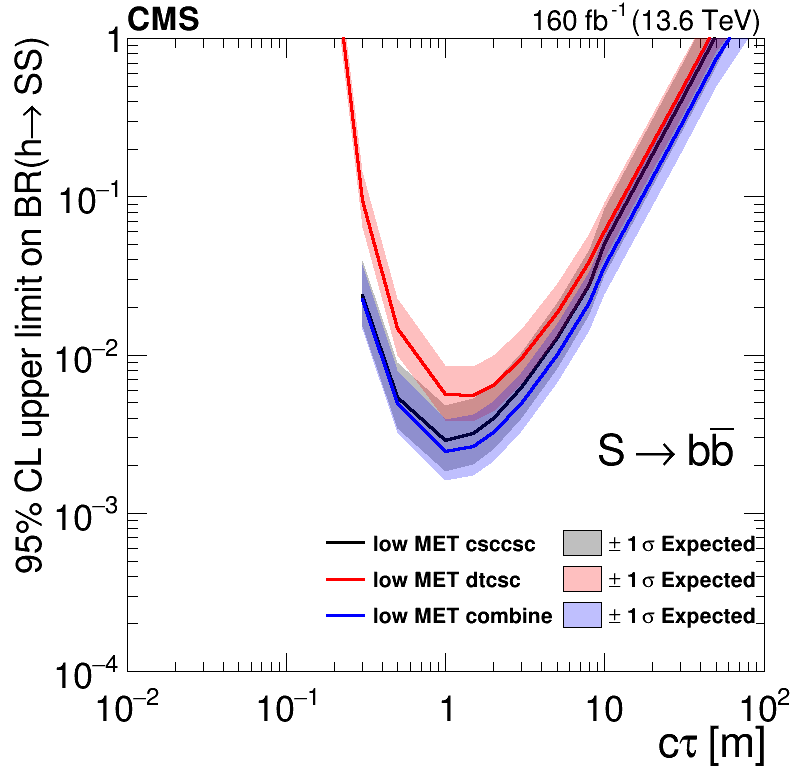

In [5]:
import os
import importlib
importlib.reload(sys.modules['CMS_lumi'])

opac_1sig = 0.25
opac_2sig = 0.1

print(decay)
leg = rt.TLegend(0.4,0.18,0.95,0.32)
leg2 = rt.TLegend(0.10,0.20,0.35,0.32)
leg.SetTextSize(0.03)
leg.SetBorderSize(0)
leg.SetEntrySeparation(0.01)
leg2.SetTextSize(0.032)
leg2.SetBorderSize(0)
leg2.SetEntrySeparation(0.01)


c = rt.TCanvas('c','c', 800, 800)
c.SetRightMargin(0.04)

rt.gStyle.SetOptFit(1011)
ctaus_m = ctaus/1000
#     print(ctaus_m)
h = {}
h_exp1sig = {}
h_exp2sig = {}
h_obs = {}
h_others = {}
h_others_obs = {}
h_others_1sig = {}
for i, cat in enumerate(categories):
    
    
    for m in limits[cat].keys():
        print(m)
        if m not in limits[cat].keys():continue
        cond = limits[cat][m][:,2] < 1000000
        if np.count_nonzero(cond)==0:print(m, cat)
        key = f"{cat}_{m}"
        h[key] = create_TGraph(ctaus_m[cond], limits[cat][m][:,2][cond],  axis_title=['c#tau [m]', '95% CL upper limit on BR(h#rightarrow SS)'])
        h_exp1sig[key] = create_TGraph(np.hstack((ctaus_m[cond], np.flip(ctaus_m[cond]))), np.hstack((limits[cat][m][:,1][cond], np.flip(limits[cat][m][:,3][cond]))))
        mass_str = m[m.find('ms')+2:].replace('p','.')
        print(m,key,np.min(limits[cat][m][:,2][cond]), limits[cat][m][:,2][cond][ctaus_m[cond]==1])
        if '15' in m:print(limits[cat][m][:,2][cond])
        leg.AddEntry(h[key], f"low MET {cat}", "L")

        leg.AddEntry(h_exp1sig[key], "#pm 1 #sigma Expected", 'F')

        h_exp1sig[key].SetFillColorAlpha(std_color_list[i],opac_1sig)
        h[key].SetLineColor(std_color_list[i])
        h[key].SetMarkerColor(std_color_list[i])

        h[key].SetLineWidth(3)

        h[key].SetLineStyle(1)
        if decay == 'd' or decay == 'B' or decay == 'Tau': h[key].GetXaxis().SetLimits(0.01,100.0)
        else: h[key].GetXaxis().SetLimits(0.0001,100.0)
        h[key].GetYaxis().SetRangeUser(1e-4,1)

        h[key].GetXaxis().SetTitleOffset(1)
        h[key].GetYaxis().SetTitleSize(0.05)
        h[key].GetYaxis().SetTitleOffset(1.5)
        
for i,m in enumerate(h.keys()):
    h[m].Draw('LA' if i == 0 else 'Lsame')
    h_exp1sig[m].Draw('Fsame')
    print(m)
    
# for i,k in enumerate(other_limits.keys()):
#         h_others[k] = create_TGraph(other_limits[k][:,0],other_limits[k][:,3],  axis_title=['c#tau [m]', '95% CL Limit on BR'])
#         h_others_obs[k] = create_TGraph(other_limits[k][:,0],other_limits[k][:,6],  axis_title=['c#tau [m]', '95% CL Limit on BR'])
#         h_others_1sig[k] = create_TGraph(np.hstack((other_limits[k][:,0], np.flip(other_limits[k][:,0]))),\
#                                          np.hstack((other_limits[k][:,2], np.flip(other_limits[k][:,4]))),  axis_title=['c#tau [m]', '95% CL Limit on BR'])
#         leg.AddEntry(h_others[k], k, 'L')
#         h_others[k].SetLineWidth(3)
#         h_others_obs[k].SetLineWidth(3)
#         h_others_obs[k].SetLineStyle(2)
#         h_others[k].SetLineStyle(2)
        
        
#         h_others_obs[k].SetLineColor(std_color_list[i])
#         h_others[k].SetLineColor(std_color_list[i])
#         h_others[k].SetMarkerColor(std_color_list[i])
#         h_others_1sig[k].SetFillColorAlpha(std_color_list[i], opac_1sig)
#         # h_others_obs[k].Draw("Lsame")
#         # h_others[k].Draw('Lsame')
#         # h_others_1sig[k].Draw('Fsame')


tdrstyle.setTDRStyle()
CMS_lumi.cmsText     = "CMS"
iPos = 0
CMS_lumi.writeExtraText = 0
CMS_lumi.extraText   = "Preliminary"

if( iPos==0 ): CMS_lumi.relPosX = 0.12
# CMS_lumi.CMS_lumi(c, 4, 0)
CMS_lumi.CMS_lumi(c, 5, iPos)


leg.SetNColumns(2)

leg.Draw()
#     leg2.Draw()
c.SetLogy()
c.SetLogx()
c.SetTicky(1)
c.SetTickx(1)


latex = rt.TLatex()
latex.SetTextSize(0.06)
latex.SetTextFont(42)

if decay == 'd': latex.DrawLatex(9,0.002,  "S #rightarrow d#bar{d}")
elif decay == 'B': latex.DrawLatex(9,0.002, "S #rightarrow b#bar{b}")
elif decay == 'Tau': latex.DrawLatex(9,0.002, "S #rightarrow #tau^{+}#tau^{-}")

c.SaveAs(GIT_REPO + f"/limits/hmt_{m}_expected_compare.pdf")
c.SaveAs(GIT_REPO + f"/limits/hmt_{m}_expected_compare.png")
c.SaveAs(GIT_REPO + f"/limits/hmt_{m}_expected_compare.C")

tdrstyle.setTDRStyle()
c.Draw()